### Import libraries

In [2]:
%matplotlib inline
import os
import sys
import csv
import torch
import pathlib
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sb

### Import Autoencoder class

In [4]:
folder_path = str(pathlib.Path().resolve().parents[0])
print("Folder path =", folder_path)
sys.path.append(folder_path + '/Notebooks/AE_class/')
from Conv_AE_weebots_downsampled import *

Folder path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder


### Check libraries versions

In [6]:
print(f"torch version: {torch.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sb.__version__}")

torch version: 2.2.1+cu121
numpy version: 1.26.4
matplotlib version: 3.8.0
seaborn version: 0.12.2


### Check GPU

In [8]:
print("CUDA is available =", torch.cuda.is_available())
print("CUDA device count =", torch.cuda.device_count())
if torch.cuda.device_count() > 1:
    os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
#print(torch.cuda.current_device())
#print(torch.cuda.device(0))
print("CUDA device name =", torch.cuda.get_device_name(0))

CUDA is available = True
CUDA device count = 2
CUDA device name = NVIDIA RTX A5000


### Hyperparameters

In [10]:
#Experiment
model_loading = False
model_training = True
save_plots = True

reverse_envs = False

#Model
n_hidden = 200
batch_size = 256
num_epochs = 100
learning_rate = 1e-4
C_factor = 1e3
alpha = 1e5

#Others
trial_t = 0

peak_as_centroid=True
min_pix_cluster=0.02 #0.02
max_pix_cluster=0.5 #0.5
active_threshold=0.2 #0.2

envs = ['Tmaze_0', 'Tmaze_1', 'Tmaze_2']
if reverse_envs == True: envs = ['Tmaze_2', 'Tmaze_1', 'Tmaze_0']
    
actv_threshold = 0.01

### Functions

In [115]:
def format_dataset(env):
    data_path = folder_path + '/Datasets/' + env
    csv_filename = data_path + "/data.csv"

    img_filename_list = os.listdir(data_path)
    num_images = len(img_filename_list) -1 

    return data_path, csv_filename, num_images
#####################################################################

def load_csv(csv_filename):
    data = pd.read_csv(csv_filename)
    data = data[:num_images]
    position = [] 
    pos_step = []
    orientation = []
    
    for i in range(len(data)):
        pos_step = [data.X[i], data.Y[i]]
        position.append(pos_step)
        z = data.Z[i]
        orientation.append(z)
        
    position = np.array(position)
    orientation = np.array(orientation)
    
    return data, position, orientation
#####################################################################

def Load_env_dataset(env_idx):
    # Load dataset every T-maze version
    env = envs[env_idx] #Choose environment index
    data_path, csv_filename, num_images = format_dataset(env)

    print("----------  ----------  NEW ENVIRONMENT ----------  ----------")
    print("Dataset Environment    =", env)
    print("Num. Images in Dataset =", num_images)
    print("Dataset Path =", data_path)
    print("CSV path     =", csv_filename)
    
    dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)

    return dataset, csv_filename
#####################################################################

def update_data(csv_filename):
    data = pd.read_csv(csv_filename)
    #data = data[:num_images]
    
    position = [] 
    pos_step = []
    
    for i in range(len(data)):
        pos_step = [data.X[i], data.Y[i]]
        position.append(pos_step)
        
    position = np.array(position)
    print("Dataset Shape  =", dataset.shape)
    print("Position Shape =", position.shape)

    return data, position
#####################################################################

def update_model_trial(env_idx, trial):
    # Update model name for trial t
    env = envs[env_idx]
    trial_t = trial
    model_filename =  env + '-Trial' + str(trial_t) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
    foldername = 'Exp1-NEpisodes' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate)
    if reverse_envs == True:
        foldername = 'Reverse_' + foldername
    model_folder_path = folder_path + '/Models/' + foldername
    model_path = model_folder_path + '/' + model_filename
    #print('Model loaded =', model_filename)

    model = Conv_AE(n_hidden=n_hidden)
    model.load_state_dict(torch.load(model_path))

    return model
#####################################################################

def get_max_coverage(all_ratemaps, actv_threshold):
    #TDefine maximal firing coverage once, at the first trial of the first environment
    max_size = 0
    
    for i in range(len(all_ratemaps)):
        size = np.sum(all_ratemaps[i] > actv_threshold)
        if size > max_size:
            max_size = size

    print("Max. coverage =", max_size)
    return max_size
#####################################################################

def get_mean_unit_coverage_at_t(all_ratemaps, max_coverage, actv_threshold):
    #Normalize the activation coverage of each unit.
    unit_coverage = []
    
    for i in range(len(all_ratemaps)):
        unit_coverage.append(np.sum(all_ratemaps[i] > actv_threshold) / max_coverage)

    # Define mean unit coverage of (only) active units
    mean_unit_coverage = np.mean([x for x in unit_coverage if x != 0.0])
    
    return mean_unit_coverage
#####################################################################

def representative_unit_sums():
    #Take 4 reference points for measuring summed activity at representative locations
    top_left_unit_sum = np.sum(all_ratemaps[:, 40, 10])
    top_center_unit_sum = np.sum(all_ratemaps[:, 40, 25])
    top_right_unit_sum = np.sum(all_ratemaps[:, 40, 40])
    bottom_center_unit_sum = np.sum(all_ratemaps[:, 10, 25])
    return top_left_unit_sum, top_center_unit_sum, top_right_unit_sum, bottom_center_unit_sum
#####################################################################

def representative_unit_count(actv_threshold):
    #Take 4 reference points for measuring the number of active units at representative locations
    top_left_unit_count = np.sum(all_ratemaps[:, 40, 10] > actv_threshold)
    top_center_unit_count = np.sum(all_ratemaps[:, 40, 25] > actv_threshold)
    top_right_unit_count = np.sum(all_ratemaps[:, 40, 40] > actv_threshold)
    bottom_center_unit_count = np.sum(all_ratemaps[:, 10, 25] > actv_threshold)
    return top_left_unit_count, top_center_unit_count, top_right_unit_count, bottom_center_unit_count
#####################################################################

def normalize_ratemaps(ratemaps, actv_threshold):
    normal_all_ratemaps = []
    for i in range(len(all_ratemaps)):
        peak = np.max(all_ratemaps[i])
        if peak > actv_threshold:
            normal_all_ratemaps.append(all_ratemaps[i]/peak)
        else:
            normal_all_ratemaps.append(all_ratemaps[i])
    
    normal_all_ratemaps = np.array(normal_all_ratemaps)
    return normal_all_ratemaps
#####################################################################


def get_num_active_units(ratemaps, actv_threshold):
    active_units = 0
    for i in range(len(all_ratemaps)):
        peak = np.max(all_ratemaps[i])
        if peak > actv_threshold:
            active_units += 1
    return active_units

## Data processing pipeline

----------  ----------  NEW ENVIRONMENT ----------  ----------
Dataset Environment    = Tmaze_0
Num. Images in Dataset = 39510
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_0
CSV path     = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_0/data.csv
Dataset Shape  = (39510, 120, 160, 3)
Position Shape = (39510, 2)

Tmaze = 0, Trial = 0
Max. coverage = 1856
Max. coverage = 1768
Tmaze = 0, Trial = 1
Tmaze = 0, Trial = 2
Tmaze = 0, Trial = 3
Tmaze = 0, Trial = 4
Tmaze = 0, Trial = 5
Tmaze = 0, Trial = 6
Tmaze = 0, Trial = 7
Tmaze = 0, Trial = 8
Tmaze = 0, Trial = 9
Tmaze = 0, Trial = 10
Tmaze = 0, Trial = 11
Tmaze = 0, Trial = 12
Tmaze = 0, Trial = 13
Tmaze = 0, Trial = 14
Tmaze = 0, Trial = 15
Tmaze = 0, Trial = 16
Tmaze = 0, Trial = 17
Tmaze = 0, Trial = 18
Tmaze = 0, Trial = 19
Tmaze = 0, Trial = 20
Tmaze = 0, Trial = 21
Tmaze = 0, Trial = 22
Tmaze = 0, Trial = 23
Tmaze = 0, Trial = 24
Tmaze = 0, Trial = 25
Tmaze = 0

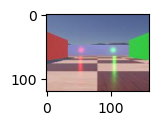

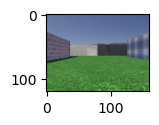

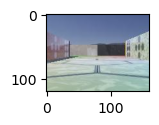

In [14]:
mean_unit_coverage_history = []
normal_mean_unit_coverage_history = []
TL_rep_unit_sum_history = []
TC_rep_unit_sum_history = []
TR_rep_unit_sum_history = []
BC_rep_unit_sum_history = []
TL_rep_unit_count_history = []
TC_rep_unit_count_history = []
TR_rep_unit_count_history = []
BC_rep_unit_count_history = []
correlation_history = []
num_active_units = []

for m in range(len(envs)):
    dataset, csv_filename = Load_env_dataset(m)
    _, position = update_data(csv_filename)
    print()
    fig = plt.figure(figsize=(2,1))
    plt.imshow(dataset[0])

    if m == 0:
        loop_range = num_epochs+1
    else:
        loop_range = num_epochs
    
    for t in range(loop_range):
        if m != 0:
            t = t+1
            
        print('Tmaze = ' + str(m) + ', Trial = ' + str(t))
        model = update_model_trial(m, t)
        
        # Get the embedding for model in trial t
        embeddings = get_latent_vectors(dataset, model, batch_size=batch_size)

        # Get all ratemaps for model units in trial t
        all_ratemaps = ratemaps(embeddings, position, n_bins=50, filter_width=3)
        normal_all_ratemaps = normalize_ratemaps(all_ratemaps, actv_threshold)

        num_active_units.append(get_num_active_units(all_ratemaps, actv_threshold))

        if m == 0 and t == 0:
            max_coverage = get_max_coverage(all_ratemaps, actv_threshold)
            normal_max_coverage = get_max_coverage(normal_all_ratemaps, actv_threshold)

        mean_unit_coverage_history.append(get_mean_unit_coverage_at_t(all_ratemaps, max_coverage, actv_threshold))
        normal_mean_unit_coverage_history.append(get_mean_unit_coverage_at_t(normal_all_ratemaps, normal_max_coverage, actv_threshold))

        # Unit activity at representative locations
        TL_sum, TC_sum, TR_sum, BC_sum = representative_unit_sums()
        TL_rep_unit_sum_history.append(TL_sum)
        TC_rep_unit_sum_history.append(TC_sum)
        TR_rep_unit_sum_history.append(TR_sum)
        BC_rep_unit_sum_history.append(BC_sum)
        
        TL_count, TC_count, TR_count, BC_count = representative_unit_count(actv_threshold)
        TL_rep_unit_count_history.append(TL_count)
        TC_rep_unit_count_history.append(TC_count)
        TR_rep_unit_count_history.append(TR_count)
        BC_rep_unit_count_history.append(BC_count)


        # Measure map correlation
        if m != 0 or t != 0:
            flat_t0 = prev_all_ratemaps.flatten()
            flat_t1 = all_ratemaps.flatten()
            corr = np.corrcoef(flat_t0, flat_t1)[0, 1]
            correlation_history.append(corr)

        prev_all_ratemaps = all_ratemaps

## Results

In [16]:
foldername = 'NEpisodes' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate)
if reverse_envs == True:
        foldername = 'Reverse_' + foldername
plot_folder_path = folder_path + '/Plots/' + foldername
model_folder_path = folder_path + '/Models/' + foldername

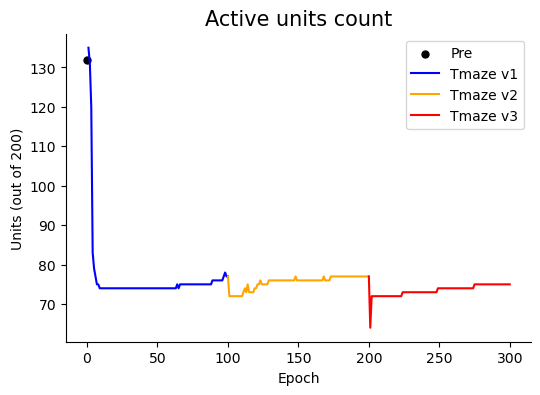

In [70]:
fig = plt.figure(figsize=(6,4))
plt.scatter(range(0, 1), num_active_units[:1], color='black', label='Pre', s=25)
plt.plot(range(1, num_epochs+1), num_active_units[1:num_epochs+1], color='blue', label='Tmaze v1')
plt.plot(range(num_epochs, (num_epochs*2)+1), num_active_units[num_epochs:(num_epochs*2)+1], color='orange', label='Tmaze v2')
plt.plot(range((num_epochs*2), (num_epochs*3)+1), num_active_units[(num_epochs*2):], color='red', label='Tmaze v3')


plt.xlabel('Epoch')
plt.ylabel('Units (out of 200)')
sb.despine()
plt.legend()
plt.title('Active units count', fontsize=15)
plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/Active_units.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Active_units.png', format='png')

In [42]:
mean_unit_coverage = [x * 100 for x in mean_unit_coverage_history] #Compute percentages

In [46]:
normal_mean_unit_coverage = [x * 100 for x in normal_mean_unit_coverage_history] #Compute percentages

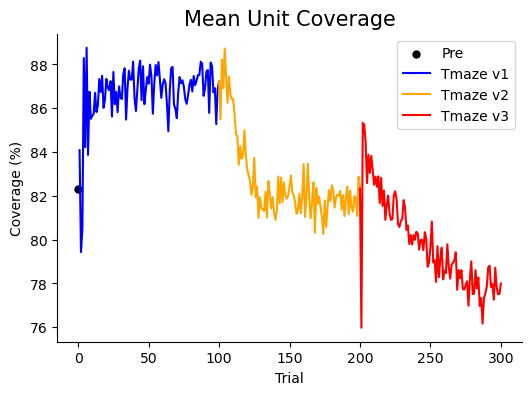

In [66]:
fig = plt.figure(figsize=(6,4))

plt.scatter(range(0, 1), mean_unit_coverage[:1], color='black', label='Pre', s=25)
plt.plot(range(1, num_epochs+1), mean_unit_coverage[1:num_epochs+1], color='blue', label='Tmaze v1')
plt.plot(range(num_epochs, (num_epochs*2)+1), mean_unit_coverage[num_epochs:(num_epochs*2)+1], color='orange', label='Tmaze v2')
plt.plot(range((num_epochs*2), (num_epochs*3)+1), mean_unit_coverage[(num_epochs*2):], color='red', label='Tmaze v3')

plt.xlabel('Trial')
plt.ylabel('Coverage (%)')
sb.despine()
plt.legend()
plt.title('Mean Unit Coverage', fontsize=15)
plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/Unit_coverage.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Unit_coverage.png', format='png')

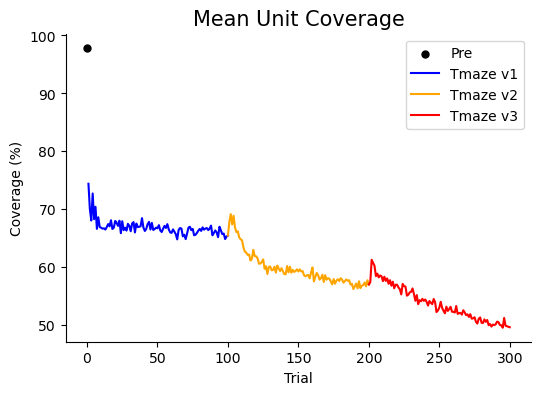

In [68]:
fig = plt.figure(figsize=(6,4))
plt.scatter(range(0, 1), normal_mean_unit_coverage[:1], color='black', label='Pre', s=25)
plt.plot(range(1, num_epochs+1), normal_mean_unit_coverage[1:num_epochs+1], color='blue', label='Tmaze v1')
plt.plot(range(num_epochs, (num_epochs*2)+1), normal_mean_unit_coverage[num_epochs:(num_epochs*2)+1], color='orange', label='Tmaze v2')
plt.plot(range((num_epochs*2), (num_epochs*3)+1), normal_mean_unit_coverage[(num_epochs*2):], color='red', label='Tmaze v3')


plt.xlabel('Trial')
plt.ylabel('Coverage (%)')
sb.despine()
plt.legend()
plt.title('Mean Unit Coverage', fontsize=15)
plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/Unit_coverage.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Unit_coverage.png', format='png')

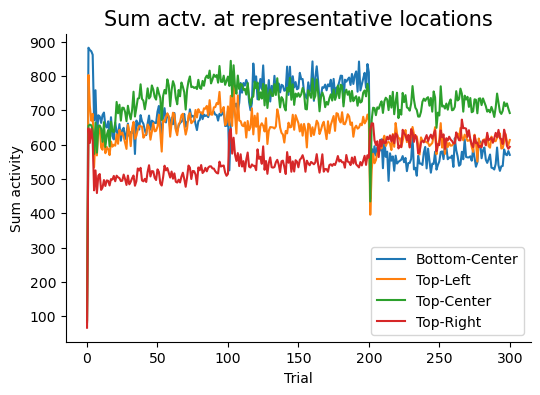

In [72]:
fig = plt.figure(figsize=(6,4))
plt.plot(BC_rep_unit_sum_history, label='Bottom-Center')
plt.plot(TL_rep_unit_sum_history, label='Top-Left')
plt.plot(TC_rep_unit_sum_history, label='Top-Center')
plt.plot(TR_rep_unit_sum_history, label='Top-Right')


plt.xlabel('Trial')
plt.ylabel('Sum activity')
sb.despine()
plt.title('Sum actv. at representative locations', fontsize=15)
plt.legend()
plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/Rep_locations.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Rep_locations.png', format='png')

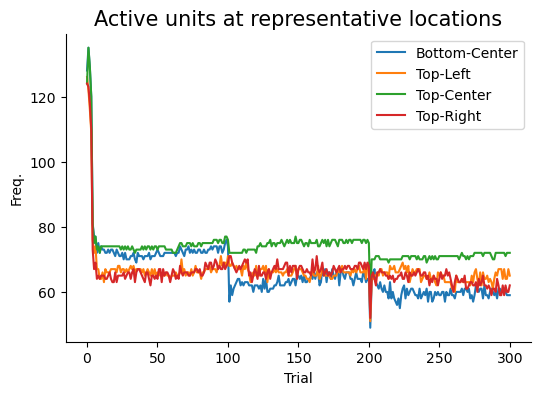

In [74]:
fig = plt.figure(figsize=(6,4))
plt.plot(BC_rep_unit_count_history, label='Bottom-Center')
plt.plot(TL_rep_unit_count_history, label='Top-Left')
plt.plot(TC_rep_unit_count_history, label='Top-Center')
plt.plot(TR_rep_unit_count_history, label='Top-Right')


plt.xlabel('Trial')
plt.ylabel('Freq.')
sb.despine()
plt.title('Active units at representative locations', fontsize=15)
plt.legend()
plt.show()

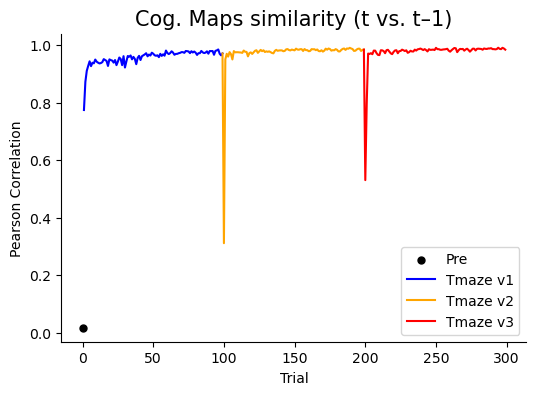

In [90]:
fig = plt.figure(figsize=(6,4))

plt.scatter(range(0, 1), correlation_history[:1], color='black', label='Pre', s=25)
plt.plot(range(1, num_epochs), correlation_history[1:num_epochs], color='blue', label='Tmaze v1')
plt.plot(range(num_epochs-1, (num_epochs*2)), correlation_history[num_epochs-1:(num_epochs*2)], color='orange', label='Tmaze v2')
plt.plot(range((num_epochs*2)-1, (num_epochs*3)), correlation_history[(num_epochs*2)-1:], color='red', label='Tmaze v3')

plt.xlabel('Trial')
plt.ylabel('Pearson Correlation')
sb.despine()
plt.legend(loc=4)
plt.title('Cog. Maps similarity (t vs. t–1)', fontsize=15)
plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/Map_similarity.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Map_similarity.png', format='png')

In [94]:
loss_csv_filename = model_folder_path + '/loss_history.csv'

history_loss = []
with open(loss_csv_filename, mode='r', newline='') as file:
    reader = csv.DictReader(file)
    for row in reader:
        value = row.get('Image_loss')
        history_loss.append(float(value))


In [96]:
len(history_loss)

300

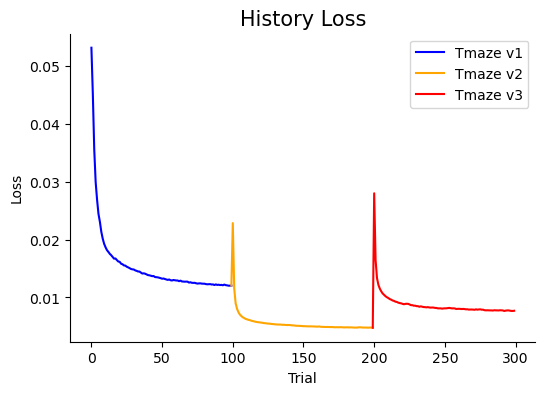

In [104]:
fig = plt.figure(figsize=(6,4))
plt.plot(range(0, 100), history_loss[:100], color='blue', label='Tmaze v1')
plt.plot(range(99, 200), history_loss[99:200], color='orange', label='Tmaze v2')
plt.plot(range(199, 300), history_loss[199:], color='red', label='Tmaze v3')

plt.xlabel('Trial')
plt.ylabel('Loss')
sb.despine()
plt.legend()
plt.title('History Loss', fontsize=15)
plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/History_loss.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/History_loss.png', format='png')

In [106]:
def plot_img_reconstruction(dataset, mt0, mt50, mt100):
    img_indx = 0

    fig = plt.figure(figsize=(14,3))
    plt.subplot(141)
    plt.imshow(dataset[img_indx])
    plt.suptitle('Image reconstruction', fontsize=15)
    plt.title('Input', fontsize=10)
    plt.ylabel('Tmaze v3')
    
    plt.subplot(142)
    plt.imshow(predict(dataset[img_indx], mt0))
    plt.title('Trial 0', fontsize=10)

    plt.subplot(143)
    plt.imshow(predict(dataset[img_indx], mt50))
    plt.title('Trial 50', fontsize=10)

    plt.subplot(144)
    plt.imshow(predict(dataset[img_indx], mt100))
    plt.title('Trial 100', fontsize=10)

    plt.show()
    
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Tmaze3_img_recon.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Tmaze3_img_recon.png', format='png')

----------  ----------  NEW ENVIRONMENT ----------  ----------
Dataset Environment    = Tmaze_0
Num. Images in Dataset = 39510
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_0
CSV path     = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_0/data.csv


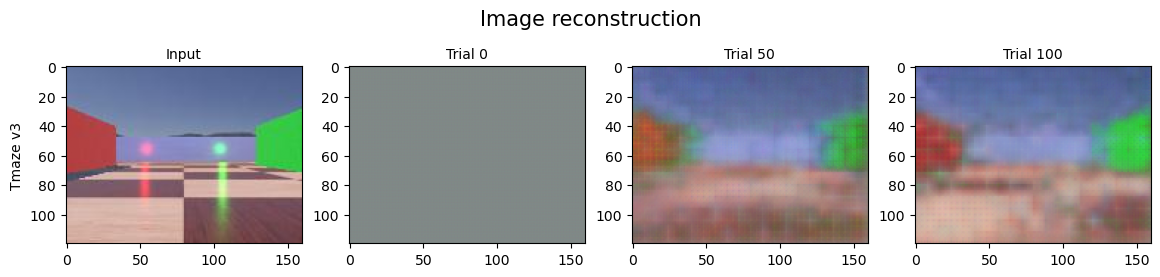

In [108]:
m = 0
t = 0

mt0 = update_model_trial(m, t)

t = 50
mt50 = update_model_trial(m, t)

t = 100
mt100 = update_model_trial(m, t)

dataset, _ = Load_env_dataset(m)
plot_img_reconstruction(dataset, mt0, mt50, mt100)

----------  ----------  NEW ENVIRONMENT ----------  ----------
Dataset Environment    = Tmaze_1
Num. Images in Dataset = 39906
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_1
CSV path     = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_1/data.csv


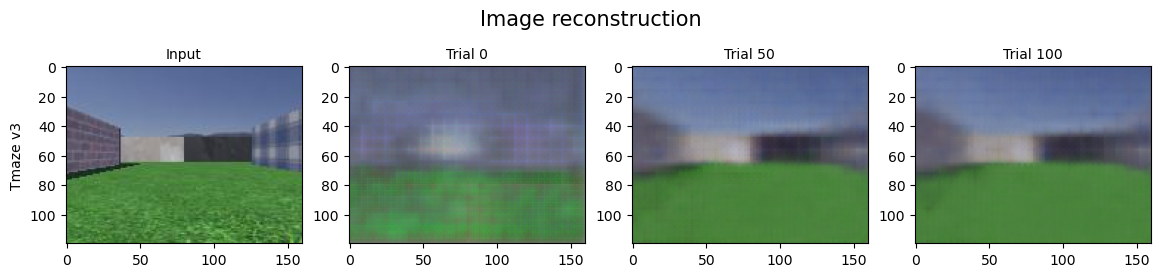

In [121]:
m = 1
t = 1

mt1 = update_model_trial(m, t)

t = 50
mt50 = update_model_trial(m, t)

t = 100
mt100 = update_model_trial(m, t)

dataset, _ = Load_env_dataset(m)
plot_img_reconstruction(dataset, mt1, mt50, mt100)

----------  ----------  NEW ENVIRONMENT ----------  ----------
Dataset Environment    = Tmaze_2
Num. Images in Dataset = 41956
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_2
CSV path     = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_2/data.csv


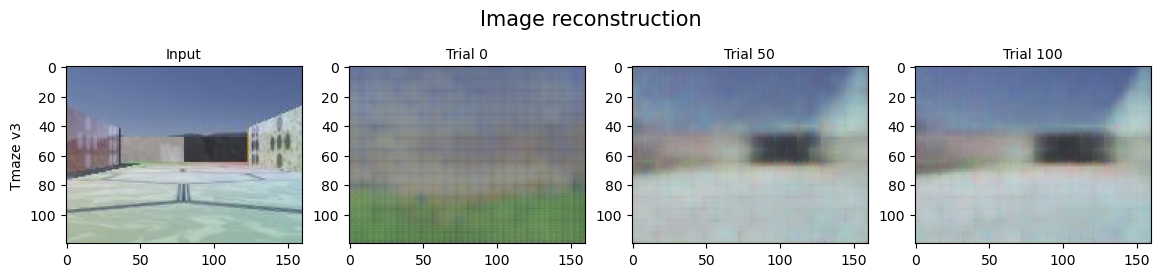

In [122]:
m = 2
t = 1

mt1 = update_model_trial(m, t)

t = 50
mt50 = update_model_trial(m, t)

t = 100
mt100 = update_model_trial(m, t)

dataset, _ = Load_env_dataset(m)
plot_img_reconstruction(dataset, mt1, mt50, mt100)

In [125]:
def hide_ticks(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

def add_colorbar(ax, im):
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction & pad for size and spacing
    cbar.ax.tick_params(labelsize=8)  # Adjust tick label size

In [127]:
def update_model_dataset(m):
    dataset, csv_filename = Load_env_dataset(m)
    print("Dataset = ", csv_filename)
    _, position = update_data(csv_filename)
    return dataset, position

In [129]:
def update_trial_ratemaps(m, t, dataset, position):
    model = update_model_trial(m, t)
    
    # Get the embedding for model in trial t
    embeddings = get_latent_vectors(dataset, model, batch_size=batch_size)
    
    # Get all ratemaps for model units in trial t
    all_ratemaps = ratemaps(embeddings, position, n_bins=50, filter_width=3)
    return all_ratemaps

In [172]:
unit_1 = 0
unit_2 = 1
unit_3 = 39
unit_4 = 14
unit_5 = 15

In [203]:
m = 0
t = 1
dataset, position = update_model_dataset(m)
all_ratemaps = update_trial_ratemaps(m, t, dataset, position)

m0t0_ratemap25 = all_ratemaps[unit_1]
m0t0_ratemap50 = all_ratemaps[unit_2]
m0t0_ratemap100 = all_ratemaps[unit_3]
m0t0_ratemap125 = all_ratemaps[unit_4]
m0t0_ratemap150 = all_ratemaps[unit_5]

----------  ----------  NEW ENVIRONMENT ----------  ----------
Dataset Environment    = Tmaze_0
Num. Images in Dataset = 39510
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_0
CSV path     = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_0/data.csv
Dataset =  C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_0/data.csv
Dataset Shape  = (41956, 120, 160, 3)
Position Shape = (39510, 2)


In [175]:
t = 10
all_ratemaps = update_trial_ratemaps(m, t, dataset, position)

m0t10_ratemap25 = all_ratemaps[unit_1]
m0t10_ratemap50 = all_ratemaps[unit_2]
m0t10_ratemap100 = all_ratemaps[unit_3]
m0t10_ratemap125 = all_ratemaps[unit_4]
m0t10_ratemap150 = all_ratemaps[unit_5]

In [176]:
t = 100
all_ratemaps = update_trial_ratemaps(m, t, dataset, position)

m0t100_ratemap25 = all_ratemaps[unit_1]
m0t100_ratemap50 = all_ratemaps[unit_2]
m0t100_ratemap100 = all_ratemaps[unit_3]
m0t100_ratemap125 = all_ratemaps[unit_4]
m0t100_ratemap150 = all_ratemaps[unit_5]

In [207]:
m = 1
t = 0
dataset, position = update_model_dataset(m)
all_ratemaps = update_trial_ratemaps(m, t, dataset, position)

m1t0_ratemap25 = all_ratemaps[unit_1]
m1t0_ratemap50 = all_ratemaps[unit_2]
m1t0_ratemap100 = all_ratemaps[unit_3]
m1t0_ratemap125 = all_ratemaps[unit_4]
m1t0_ratemap150 = all_ratemaps[unit_5]

----------  ----------  NEW ENVIRONMENT ----------  ----------
Dataset Environment    = Tmaze_1
Num. Images in Dataset = 39906
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_1
CSV path     = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_1/data.csv
Dataset =  C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_1/data.csv
Dataset Shape  = (39510, 120, 160, 3)
Position Shape = (39906, 2)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\specs\\Desktop\\Robotology\\Repos\\HPC-VTA_Autoencoder/Models/Exp1-NEpisodes100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001/Tmaze_1-Trial0of100-NHidden200-BSize256-C1000.0-A100000.0-LR0.0001.pth'

In [179]:
t = 10
all_ratemaps = update_trial_ratemaps(m, t, dataset, position)

m1t10_ratemap25 = all_ratemaps[unit_1]
m1t10_ratemap50 = all_ratemaps[unit_2]
m1t10_ratemap100 = all_ratemaps[unit_3]
m1t10_ratemap125 = all_ratemaps[unit_4]
m1t10_ratemap150 = all_ratemaps[unit_5]

In [180]:
t = 100
all_ratemaps = update_trial_ratemaps(m, t, dataset, position)

m1t100_ratemap25 = all_ratemaps[unit_1]
m1t100_ratemap50 = all_ratemaps[unit_2]
m1t100_ratemap100 = all_ratemaps[unit_3]
m1t100_ratemap125 = all_ratemaps[unit_4]
m1t100_ratemap150 = all_ratemaps[unit_5]

In [182]:
m = 2
t = 1
dataset, position = update_model_dataset(m)
all_ratemaps = update_trial_ratemaps(m, t, dataset, position)

m2t0_ratemap25 = all_ratemaps[unit_1]
m2t0_ratemap50 = all_ratemaps[unit_2]
m2t0_ratemap100 = all_ratemaps[unit_3]
m2t0_ratemap125 = all_ratemaps[unit_4]
m2t0_ratemap150 = all_ratemaps[unit_5]

----------  ----------  NEW ENVIRONMENT ----------  ----------
Dataset Environment    = Tmaze_2
Num. Images in Dataset = 41956
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_2
CSV path     = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_2/data.csv
Dataset =  C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_2/data.csv
Dataset Shape  = (39906, 120, 160, 3)
Position Shape = (41956, 2)


In [183]:
t = 10
all_ratemaps = update_trial_ratemaps(m, t, dataset, position)

m2t10_ratemap25 = all_ratemaps[unit_1]
m2t10_ratemap50 = all_ratemaps[unit_2]
m2t10_ratemap100 = all_ratemaps[unit_3]
m2t10_ratemap125 = all_ratemaps[unit_4]
m2t10_ratemap150 = all_ratemaps[unit_5]

In [184]:
t = 100
all_ratemaps = update_trial_ratemaps(m, t, dataset, position)

m2t100_ratemap25 = all_ratemaps[unit_1]
m2t100_ratemap50 = all_ratemaps[unit_2]
m2t100_ratemap100 = all_ratemaps[unit_3]
m2t100_ratemap125 = all_ratemaps[unit_4]
m2t100_ratemap150 = all_ratemaps[unit_5]

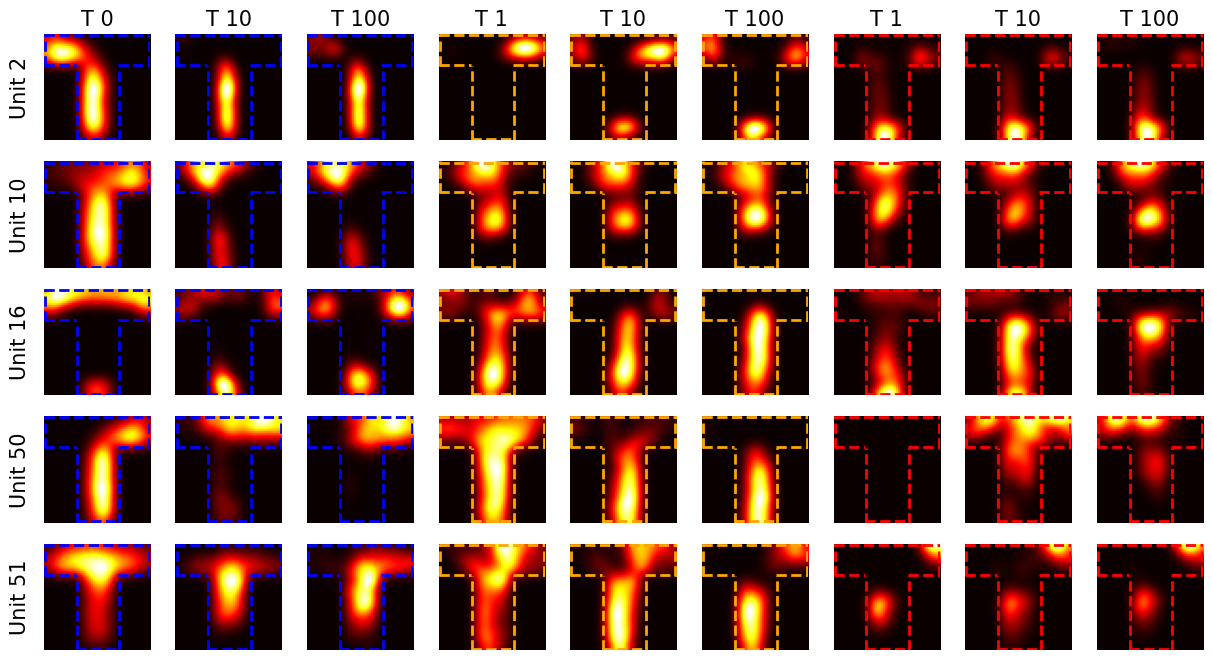

In [209]:
fig, axes = plt.subplots(5, 9, figsize=(15, 8))

colors = ['blue'] * 3 + ['orange'] * 3 + ['red'] * 3

for i, ax in enumerate(axes.flatten()):
    # Determine the column index (0–8)
    col = i % 9
    color = colors[col]

    # Draw dashed T-maze using the color for this column
    ax.axhline(y=35, xmin=0, xmax=0.3, color=color, linestyle='--', linewidth=2)
    ax.axhline(y=35, xmin=0.7, xmax=1, color=color, linestyle='--', linewidth=2)
    ax.axhline(y=49, xmin=0, xmax=1, color=color, linestyle='--', linewidth=2)
    ax.axhline(y=0, xmin=0.3, xmax=0.7, color=color, linestyle='--', linewidth=2)
    ax.axvline(x=35, ymin=0, ymax=0.7, color=color, linestyle='--', linewidth=2)
    ax.axvline(x=15, ymin=0, ymax=0.7, color=color, linestyle='--', linewidth=2)
    ax.axvline(x=0, ymin=0.7, ymax=1, color=color, linestyle='--', linewidth=2)
    ax.axvline(x=49, ymin=0.7, ymax=1, color=color, linestyle='--', linewidth=2)

    
################### M0 T0 ###################
im = axes[0, 0].imshow(m0t0_ratemap25, cmap='hot', origin='lower')
axes[0, 0].set_title('T 0', fontsize=15)
axes[0, 0].set_ylabel("Unit 2", fontsize=15, labelpad=10)
hide_ticks(axes[0, 0])

im = axes[1, 0].imshow(m0t0_ratemap50, cmap='hot', origin='lower')
axes[1, 0].set_ylabel("Unit 10", fontsize=15, labelpad=10)
hide_ticks(axes[1, 0])

im = axes[2, 0].imshow(m0t0_ratemap100, cmap='hot', origin='lower')
axes[2, 0].set_ylabel("Unit 16", fontsize=15, labelpad=10)
hide_ticks(axes[2, 0])

im = axes[3, 0].imshow(m0t0_ratemap125, cmap='hot', origin='lower')
axes[3, 0].set_ylabel("Unit 50", fontsize=15, labelpad=10)
hide_ticks(axes[3, 0])

im = axes[4, 0].imshow(m0t0_ratemap150, cmap='hot', origin='lower')
axes[4, 0].set_ylabel("Unit 51", fontsize=15, labelpad=10)
hide_ticks(axes[4, 0])


################### M0 T10 ###################
im = axes[0, 1].imshow(m0t10_ratemap25, cmap='hot', origin='lower')
axes[0, 1].set_title('T 10', fontsize=15)
hide_ticks(axes[0, 1])

im = axes[1, 1].imshow(m0t10_ratemap50, cmap='hot', origin='lower')
hide_ticks(axes[1, 1])

im = axes[2, 1].imshow(m0t10_ratemap100, cmap='hot', origin='lower')
hide_ticks(axes[2, 1])

im = axes[3, 1].imshow(m0t10_ratemap125, cmap='hot', origin='lower')
hide_ticks(axes[3, 1])

im = axes[4, 1].imshow(m0t10_ratemap150, cmap='hot', origin='lower')
hide_ticks(axes[4, 1])


################### M0 T100 ###################
im = axes[0, 2].imshow(m0t100_ratemap25, cmap='hot', origin='lower')
axes[0, 2].set_title('T 100', fontsize=15)
hide_ticks(axes[0, 2])

im = axes[1, 2].imshow(m0t100_ratemap50, cmap='hot', origin='lower')
hide_ticks(axes[1, 2])

im = axes[2, 2].imshow(m0t100_ratemap100, cmap='hot', origin='lower')
hide_ticks(axes[2, 2])

im = axes[3, 2].imshow(m0t100_ratemap125, cmap='hot', origin='lower')
hide_ticks(axes[3, 2])

im = axes[4, 2].imshow(m0t100_ratemap150, cmap='hot', origin='lower')
hide_ticks(axes[4, 2])


################### M1 T0 ###################
im = axes[0, 3].imshow(m1t0_ratemap25, cmap='hot', origin='lower')
axes[0, 3].set_title('T 1', fontsize=15)
hide_ticks(axes[0, 3])

im = axes[1, 3].imshow(m1t0_ratemap50, cmap='hot', origin='lower')
hide_ticks(axes[1, 3])

im = axes[2, 3].imshow(m1t0_ratemap100, cmap='hot', origin='lower')
hide_ticks(axes[2, 3])

im = axes[3, 3].imshow(m1t0_ratemap125, cmap='hot', origin='lower')
hide_ticks(axes[3, 3])

im = axes[4, 3].imshow(m1t0_ratemap150, cmap='hot', origin='lower')
hide_ticks(axes[4, 3])

################### M1 T10 ###################
im = axes[0, 4].imshow(m1t10_ratemap25, cmap='hot', origin='lower')
axes[0, 4].set_title('T 10', fontsize=15)
hide_ticks(axes[0, 4])

im = axes[1, 4].imshow(m1t10_ratemap50, cmap='hot', origin='lower')
hide_ticks(axes[1, 4])

im = axes[2, 4].imshow(m1t10_ratemap100, cmap='hot', origin='lower')
hide_ticks(axes[2, 4])

im = axes[3, 4].imshow(m1t10_ratemap125, cmap='hot', origin='lower')
hide_ticks(axes[3, 4])

im = axes[4, 4].imshow(m1t10_ratemap150, cmap='hot', origin='lower')
hide_ticks(axes[4, 4])

################### M1 T100 ###################
im = axes[0, 5].imshow(m1t100_ratemap25, cmap='hot', origin='lower')
axes[0, 5].set_title('T 100', fontsize=15)
hide_ticks(axes[0, 5])

im = axes[1, 5].imshow(m1t100_ratemap50, cmap='hot', origin='lower')
hide_ticks(axes[1, 5])

im = axes[2, 5].imshow(m1t100_ratemap100, cmap='hot', origin='lower')
hide_ticks(axes[2, 5])

im = axes[3, 5].imshow(m1t100_ratemap125, cmap='hot', origin='lower')
hide_ticks(axes[3, 5])

im = axes[4, 5].imshow(m1t100_ratemap150, cmap='hot', origin='lower')
hide_ticks(axes[4, 5])

################### M2 T0 ###################
im = axes[0, 6].imshow(m2t0_ratemap25, cmap='hot', origin='lower')
axes[0, 6].set_title('T 1', fontsize=15)
hide_ticks(axes[0, 6])

im = axes[1, 6].imshow(m2t0_ratemap50, cmap='hot', origin='lower')
hide_ticks(axes[1, 6])

im = axes[2, 6].imshow(m2t0_ratemap100, cmap='hot', origin='lower')
hide_ticks(axes[2, 6])

im = axes[3, 6].imshow(m2t0_ratemap125, cmap='hot', origin='lower')
hide_ticks(axes[3, 6])

im = axes[4, 6].imshow(m2t0_ratemap150, cmap='hot', origin='lower')
hide_ticks(axes[4, 6])

################### M2 T10 ###################
im = axes[0, 7].imshow(m2t10_ratemap25, cmap='hot', origin='lower')
axes[0, 7].set_title('T 10', fontsize=15)
hide_ticks(axes[0, 7])

im = axes[1, 7].imshow(m2t10_ratemap50, cmap='hot', origin='lower')
hide_ticks(axes[1, 7])

im = axes[2, 7].imshow(m2t10_ratemap100, cmap='hot', origin='lower')
hide_ticks(axes[2, 7])

im = axes[3, 7].imshow(m2t10_ratemap125, cmap='hot', origin='lower')
hide_ticks(axes[3, 7])

im = axes[4, 7].imshow(m2t10_ratemap150, cmap='hot', origin='lower')
hide_ticks(axes[4, 7])

################### M2 T100 ###################
im = axes[0, 8].imshow(m2t100_ratemap25, cmap='hot', origin='lower')
axes[0, 8].set_title('T 100', fontsize=15)
hide_ticks(axes[0, 8])

im = axes[1, 8].imshow(m2t100_ratemap50, cmap='hot', origin='lower')
hide_ticks(axes[1, 8])

im = axes[2, 8].imshow(m2t100_ratemap100, cmap='hot', origin='lower')
hide_ticks(axes[2, 8])

im = axes[3, 8].imshow(m2t100_ratemap125, cmap='hot', origin='lower')
hide_ticks(axes[3, 8])

im = axes[4, 8].imshow(m2t100_ratemap150, cmap='hot', origin='lower')
hide_ticks(axes[4, 8])

plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/example_units.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/example_units.png', format='png')

In [187]:
peak_activity = []
for i in range(n_hidden):
    peak_activity.append(np.max(all_ratemaps[i]))

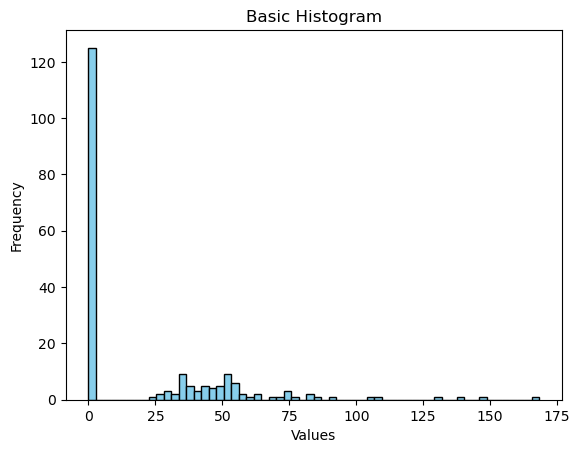

In [188]:
plt.hist(peak_activity, bins=60, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Basic Histogram')

# Display the plot
plt.show()

In [189]:
plot_ratemaps(all_ratemaps[0:100], plot_folder_path, save=False)

In [ ]:
np.zeros([50,50])

In [215]:
all_epochs_ratemaps = []

for m in range(len(envs)):
    dataset, csv_filename = Load_env_dataset(m)
    _, position = update_data(csv_filename)
    print()
    fig = plt.figure(figsize=(2,1))
    plt.imshow(dataset[0])

    if m == 0:
        loop_range = num_epochs+1
    else:
        loop_range = num_epochs
    
    for t in range(loop_range):
        if m != 0:
            t = t+1
            
        print('Tmaze = ' + str(m) + ', Trial = ' + str(t))
        model = update_model_trial(m, t)
        
        # Get the embedding for model in trial t
        embeddings = get_latent_vectors(dataset, model, batch_size=batch_size)

        # Get all ratemaps for model units in trial t
        all_ratemaps = ratemaps(embeddings, position, n_bins=50, filter_width=3)
        all_epochs_ratemaps.append(all_ratemaps)

----------  ----------  NEW ENVIRONMENT ----------  ----------
Dataset Environment    = Tmaze_0
Num. Images in Dataset = 39510
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_0
CSV path     = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder/Datasets/Tmaze_0/data.csv


KeyboardInterrupt: 

In [ ]:
img_indx = 0

fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(dataset[img_indx])
plt.suptitle('Example image', fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(dataset[img_indx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()

In [ ]:
# Get the embedding for model in trial t
embeddings = get_latent_vectors(dataset, model, batch_size=batch_size)

# Get all ratemaps for model units in trial t
all_ratemaps = ratemaps(embeddings, position, n_bins=50, filter_width=3)

In [ ]:
plot_ratemaps(all_ratemaps[0:100], plot_folder_path, save=save_plots)

In [ ]:
correlation_history

In [ ]:
trial_t = 100
model_filename =  env + '_' + 'trial-' + str(trial_t) + '_' + str(n_hidden) + 'nHidden_' + str(learning_rate) + 'LR.pth'
model_path = folder_path + '/Models/' + model_filename
torch.save(model.state_dict(), model_path)

In [ ]:
env = envs[1]
data_path, csv_filename, num_images = format_dataset(env)
dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
dataset.shape

In [ ]:
if model_training == True:
    train_loader = create_dataloader(dataset, batch_size=batch_size)
    for i in range(num_epochs):
        trial_t = i
        model_filename =  env + '_' + 'trial-' + str(trial_t) + '_' + str(n_hidden) + 'nHidden_' + str(learning_rate) + 'LR.pth'
        model_path = folder_path + '/Models/' + model_filename
        torch.save(model.state_dict(), model_path)
    
        history, _ = train_autoencoder(model, train_loader, num_epochs=1, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)
        loss.append(history[0])

In [ ]:
trial_t = 100
model_filename =  env + '_' + 'trial-' + str(trial_t) + '_' + str(n_hidden) + 'nHidden_' + str(learning_rate) + 'LR.pth'
model_path = folder_path + '/Models/' + model_filename
torch.save(model.state_dict(), model_path)

In [ ]:
env = envs[2]
data_path, csv_filename, num_images = format_dataset(env)
dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
dataset.shape

In [ ]:
if model_training == True:
    train_loader = create_dataloader(dataset, batch_size=batch_size)
    for i in range(num_epochs):
        trial_t = i
        model_filename =  env + '_' + 'trial-' + str(trial_t) + '_' + str(n_hidden) + 'nHidden_' + str(learning_rate) + 'LR.pth'
        model_path = folder_path + '/Models/' + model_filename
        torch.save(model.state_dict(), model_path)
    
        history, _ = train_autoencoder(model, train_loader, num_epochs=1, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)
        loss.append(history[0])

In [ ]:
trial_t = 100
model_filename =  env + '_' + 'trial-' + str(trial_t) + '_' + str(n_hidden) + 'nHidden_' + str(learning_rate) + 'LR.pth'
model_path = folder_path + '/Models/' + model_filename
torch.save(model.state_dict(), model_path)

In [ ]:
if model_training == True:
    fig = plt.figure(figsize=(6,4))
    plt.plot(loss)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    sb.despine()
    plt.suptitle(env + ' history loss', fontsize=15)
    plt.title('Final loss = ' + str(round(history[-1], 5)), fontsize=10)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/History_loss.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/History_loss.png', format='png')

In [ ]:
#Saving loss history in a CSV file
loss_csv_filename = plot_folder_path + '/loss_history.csv'
with open(loss_csv_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Image_loss'])

    # If you want each element on a new line
    for item in history:
        writer.writerow([item])

In [ ]:
if model_saving == True:
    print(model_path)
    torch.save(model.state_dict(), model_path)

### Model loading

In [ ]:
model = Conv_AE(n_hidden=n_hidden)
model.load_state_dict(torch.load(model_path))
print("Model loaded:", model_path)

### Get embeddings

In [ ]:
embeddings = get_latent_vectors(dataset, model, batch_size=batch_size)

### Check results

In [ ]:
img_indx = 0

fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(dataset[img_indx])
plt.suptitle('Example image', fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(dataset[img_indx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/Image_reconstruction.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Image_reconstruction.png', format='png')

In [ ]:
all_ratemaps = ratemaps(embeddings, position, n_bins=50, filter_width=3)

In [ ]:
plot_ratemaps(all_ratemaps[0:100], plot_folder_path, save=save_plots)

In [ ]:
sscp = np.dot(embeddings.T, embeddings)

fig = plt.figure(figsize=(7,6))
plt.title('Sums of Squares and Cross Products Matrix', fontsize=15)
plt.imshow(sscp, origin='lower')
plt.xlabel('Units')
plt.ylabel('Units')
plt.colorbar()
plt.show()
if save_plots == True:
    fig.savefig(plot_folder_path + '/sscp.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/sscp.png', format='png')

In [ ]:
# Define fields, centroids and sizes
all_num_fields, centroids, sizes = stats_place_fields(all_ratemaps, peak_as_centroid=peak_as_centroid, min_pix_cluster=min_pix_cluster, max_pix_cluster=max_pix_cluster, active_threshold=active_threshold)
centroids_per_field, sizes_per_field = format_centroids(all_num_fields, centroids, sizes)

In [ ]:
plot_place_field_hist(all_num_fields, plot_folder_path, save=save_plots)

In [ ]:
unit = 0
plot_single_ratemap_density(all_ratemaps, unit, all_num_fields, sizes_per_field, centroids_per_field, plot_folder_path, figsize=(5,5), save=save_plots)

In [ ]:
#Lets take 4 reference points for measuring unit activity at representative locations
# unit[u][40][10]
# unit[u][40][25]
# unit[u][40][40]
# unit[u][10][25]
top_left_unit_sum = np.sum(all_ratemaps[:, 40, 10])
top_center_unit_sum = np.sum(all_ratemaps[:, 40, 25])
top_right_unit_sum = np.sum(all_ratemaps[:, 40, 40])
bottom_center_unit_sum = np.sum(all_ratemaps[:, 10, 25])

top_left_unit_count = np.sum(all_ratemaps[:, 40, 10] > 0.01)
top_center_unit_count = np.sum(all_ratemaps[:, 40, 25] > 0.01)
top_right_unit_count = np.sum(all_ratemaps[:, 40, 40] > 0.01)
bottom_center_unit_count = np.sum(all_ratemaps[:, 10, 25] > 0.01)

In [ ]:
for i in range(3):
    unit = i
    plot_single_ratemap_density(all_ratemaps, unit, all_num_fields, sizes_per_field, centroids_per_field, sizes, plot_folder_path)

In [ ]:
heatmap, xedges, yedges = np.histogram2d(centroids[:,1], centroids[:,0], bins=(20, 20))
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

fig = plt.figure(figsize=(7,6))
plt.imshow(heatmap.T, extent=extent, origin='lower', cmap='viridis')
plt.colorbar(label='Density')
plt.title('Centroids density', fontsize=15)
if save_plots:
    fig.savefig(plot_folder_path + '/Centroids_density.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Centroids_density.png', format='png')
plt.show()

In [ ]:
fig = plt.figure(figsize=(7,7))
for i in range(len(centroids)):
    plt.plot(centroids[:,1], centroids[:,0], 'bx', markersize=3)
plt.title("Centroids (n = " + str(len(centroids)) + ")", fontsize=15)
if save_plots:
    fig.savefig(plot_folder_path + '/Centroids.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/Centroids.png', format='png')
plt.show()

In [ ]:
zero_pf = (np.unique(all_num_fields, return_counts=True)[1][0] / n_hidden) * 100
one_pf = (np.unique(all_num_fields, return_counts=True)[1][1] / n_hidden) * 100
two_pf = (np.unique(all_num_fields, return_counts=True)[1][2] / n_hidden) * 100
three_pf = (np.unique(all_num_fields, return_counts=True)[1][3] / n_hidden) * 100

categories = ['0', '1', '2', '3']
values = [zero_pf, one_pf, two_pf, three_pf]

fig = plt.figure(figsize=(7,6))
plt.bar(categories, values)
plt.title('Percentaje of place fields', fontsize=15)
plt.xlabel('Place fields')
plt.ylabel('% of units')
if save_plots:
    fig.savefig(plot_folder_path + '/place_field_histogram.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_folder_path + '/place_field_histogram.png', format='png')
plt.show()

In [ ]:
polarmaps = polarmaps(embeddings, orientation)
plot_polarmaps(polarmaps, plot_folder_path, save=save_plots)